# Week 3 Internship Task

## Part 1: Dimensionality Reduction with PCA

**Name:** Musfira Malik  
**Internship:** AI/ML Internship  

---

### Objective
This notebook applies Principal Component Analysis (PCA) to the engineered dataset from Week 2 to reduce the number of input features while evaluating the trade-off between dimensionality reduction and model accuracy. The best model from Week 2 (Random Forest Regressor) is retrained using reduced feature sets and compared against the original full-feature model.

## Step 1: Import Required Libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Engineered Dataset

We load the same engineered dataset used in Week 2, apply the same preprocessing (dropping `date` and `High_Load`, one-hot encoding categorical columns), so that the feature set is identical to Week 2.

In [9]:
# Load the engineered dataset from Week 2
df = pd.read_csv("../data/steel_industry_engineered.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Drop date and High_Load (target leakage) — same as Week 2
df_model = df.drop(columns=["date", "High_Load"])

# One-hot encode categorical columns — same as Week 2
categorical_cols = ["WeekStatus", "Day_of_week", "Load_Type", "Month"]
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Preprocessing complete!")
print("Final shape:", df_encoded.shape)
df_encoded.head()

Dataset loaded successfully!
Shape: (35039, 15)
Preprocessing complete!
Final shape: (35039, 29)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_Factor_Ratio,WeekStatus_Weekend,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Load_Type_Maximum_Load,Load_Type_Medium_Load,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


## Step 3: Train-Test Split

We use the exact same split as Week 2 (`test_size=0.2`, `random_state=42`) so results are directly comparable. The `StandardScaler` is fit **only on the training set** to avoid data leakage, then used to transform both training and test sets.

In [10]:
# Define features and target
X = df_encoded.drop(columns=["Usage_kWh"])
y = df_encoded["Usage_kWh"]

# Same split as Week 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

# Fit scaler on training data ONLY, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete — fit on training set only (no data leakage).")

Training set shape: (28031, 28)
Testing set shape : (7008, 28)
Scaling complete — fit on training set only (no data leakage).


## Step 4: Apply PCA with All Components

PCA is first applied with `n_components` equal to the total number of features, so we can inspect how much variance each component explains before deciding how many to keep.

In [11]:
n_features = X_train_scaled.shape[1]

pca_full = PCA(n_components=n_features, random_state=42)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)
X_test_pca_full = pca_full.transform(X_test_scaled)

print(f"Total original features: {n_features}")
print("PCA fitted on training set. Explained variance ratios calculated.")

Total original features: 28
PCA fitted on training set. Explained variance ratios calculated.


## Step 5: Scree Plot — Explained Variance per Component

The scree plot shows how much variance each individual principal component explains. Components are usually ranked in decreasing order of importance.

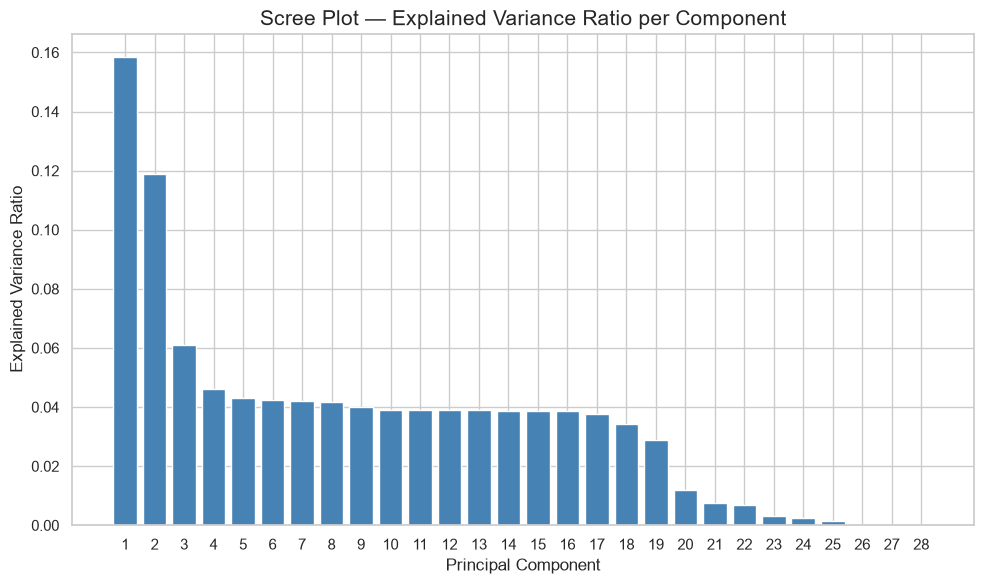

In [12]:
explained_variance = pca_full.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_features + 1), explained_variance, color="steelblue")
plt.title("Scree Plot — Explained Variance Ratio per Component", fontsize=15)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, n_features + 1))

plt.tight_layout()
plt.savefig("../static/scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6: Cumulative Explained Variance

We plot the cumulative explained variance as components are added, and draw a horizontal line at 95% to identify the minimum number of components needed to retain 95% of the information in the original data.

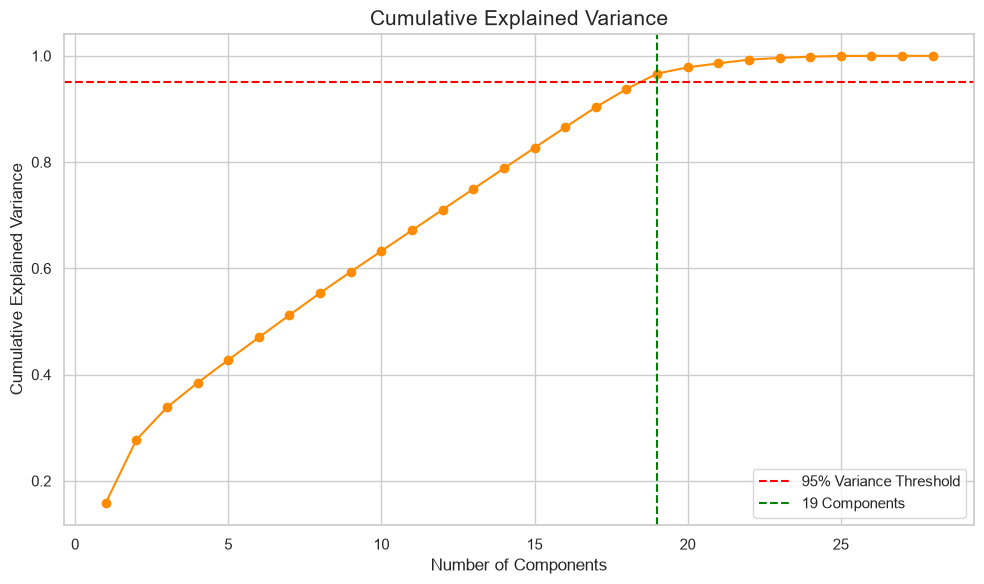

Number of components needed to reach 95% variance: 19


In [13]:
cumulative_variance = np.cumsum(explained_variance)

# Find number of components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_features + 1), cumulative_variance, marker="o", color="darkorange")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% Variance Threshold")
plt.axvline(x=n_components_95, color="green", linestyle="--", 
            label=f"{n_components_95} Components")

plt.title("Cumulative Explained Variance", fontsize=15)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()

plt.tight_layout()
plt.savefig("../static/cumulative_variance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Number of components needed to reach 95% variance: {n_components_95}")

## Step 7: Retrain Best Model Using 3 PCA Components

The best model from Week 2 (Random Forest Regressor) is retrained here using only the first 3 principal components as input features.

In [14]:
# Use only first 3 components
X_train_pca3 = X_train_pca_full[:, :3]
X_test_pca3 = X_test_pca_full[:, :3]

model_pca3 = RandomForestRegressor(random_state=42)
model_pca3.fit(X_train_pca3, y_train)

y_pred_pca3 = model_pca3.predict(X_test_pca3)

mae_pca3 = mean_absolute_error(y_test, y_pred_pca3)
rmse_pca3 = np.sqrt(mean_squared_error(y_test, y_pred_pca3))
r2_pca3 = r2_score(y_test, y_pred_pca3)

print("--- Random Forest (3 PCA Components) ---")
print(f"MAE  : {mae_pca3:.4f}")
print(f"RMSE : {rmse_pca3:.4f}")
print(f"R2   : {r2_pca3:.4f}")

--- Random Forest (3 PCA Components) ---
MAE  : 2.8291
RMSE : 5.7592
R2   : 0.9704


## Step 8: Retrain Best Model Using 95%-Variance Components

The model is retrained again, this time using the number of components identified in Step 6 that capture 95% of the variance.

In [15]:
# Use components needed for 95% variance
X_train_pca95 = X_train_pca_full[:, :n_components_95]
X_test_pca95 = X_test_pca_full[:, :n_components_95]

model_pca95 = RandomForestRegressor(random_state=42)
model_pca95.fit(X_train_pca95, y_train)

y_pred_pca95 = model_pca95.predict(X_test_pca95)

mae_pca95 = mean_absolute_error(y_test, y_pred_pca95)
rmse_pca95 = np.sqrt(mean_squared_error(y_test, y_pred_pca95))
r2_pca95 = r2_score(y_test, y_pred_pca95)

print(f"--- Random Forest ({n_components_95} PCA Components — 95% Variance) ---")
print(f"MAE  : {mae_pca95:.4f}")
print(f"RMSE : {rmse_pca95:.4f}")
print(f"R2   : {r2_pca95:.4f}")

--- Random Forest (19 PCA Components — 95% Variance) ---
MAE  : 1.7224
RMSE : 3.5612
R2   : 0.9887


## Step 9: Original Model (No PCA) — Week 2 Baseline

For comparison, the Random Forest model is also retrained using the original, unreduced feature set (scaled, but without PCA).

In [16]:
model_original = RandomForestRegressor(random_state=42)
model_original.fit(X_train_scaled, y_train)

y_pred_original = model_original.predict(X_test_scaled)

mae_original = mean_absolute_error(y_test, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_original = r2_score(y_test, y_pred_original)

print("--- Random Forest (Original — No PCA) ---")
print(f"MAE  : {mae_original:.4f}")
print(f"RMSE : {rmse_original:.4f}")
print(f"R2   : {r2_original:.4f}")

--- Random Forest (Original — No PCA) ---
MAE  : 0.3360
RMSE : 1.0283
R2   : 0.9991


## Step 10: Compare RMSE and R² Across All Three Versions

We compare the performance of the original (no PCA) model, the 3-component PCA model, and the 95%-variance PCA model.

                   Model Version      MAE     RMSE       R2
               Original (No PCA) 0.335995 1.028265 0.999055
                3 PCA Components 2.829136 5.759171 0.970357
19 PCA Components (95% Variance) 1.722421 3.561167 0.988666


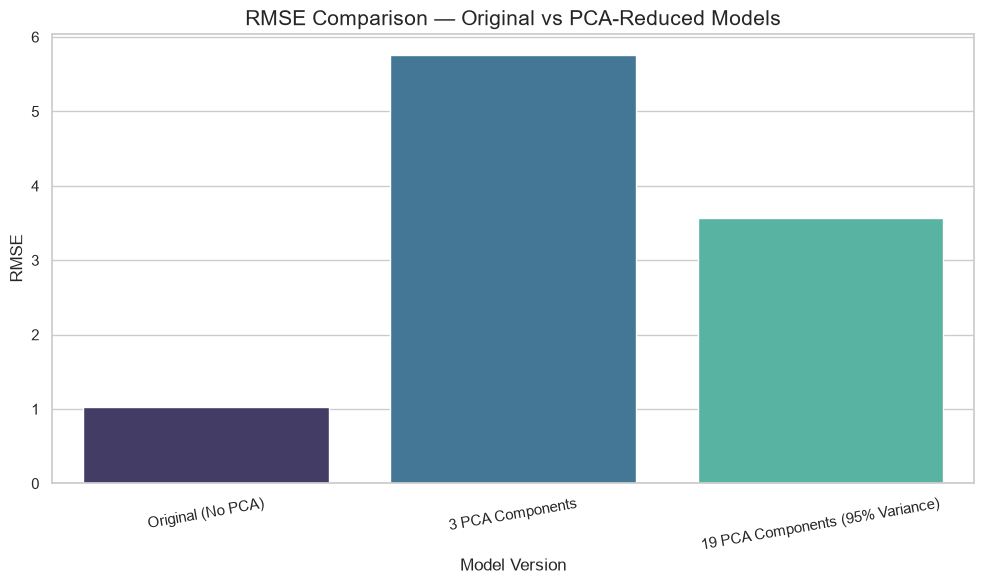

,Model Version,MAE,RMSE,R2
0,Original (No PCA),0.335995,1.028265,0.999055
1,3 PCA Components,2.829136,5.759171,0.970357
2,19 PCA Components (95% Variance),1.722421,3.561167,0.988666


In [17]:
comparison = pd.DataFrame({
    "Model Version": [
        "Original (No PCA)",
        "3 PCA Components",
        f"{n_components_95} PCA Components (95% Variance)"
    ],
    "MAE": [mae_original, mae_pca3, mae_pca95],
    "RMSE": [rmse_original, rmse_pca3, rmse_pca95],
    "R2": [r2_original, r2_pca3, r2_pca95]
})

print(comparison.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison, x="Model Version", y="RMSE", palette="mako")
plt.title("RMSE Comparison — Original vs PCA-Reduced Models", fontsize=15)
plt.ylabel("RMSE")
plt.xticks(rotation=10)

plt.tight_layout()
plt.savefig("../static/pca_rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

comparison

## Step 11: Loading Heatmap — Feature Contribution to Top 3 Components

This heatmap shows how much each original feature contributes ("loads onto") each of the first three principal components. Larger absolute values indicate stronger contribution.

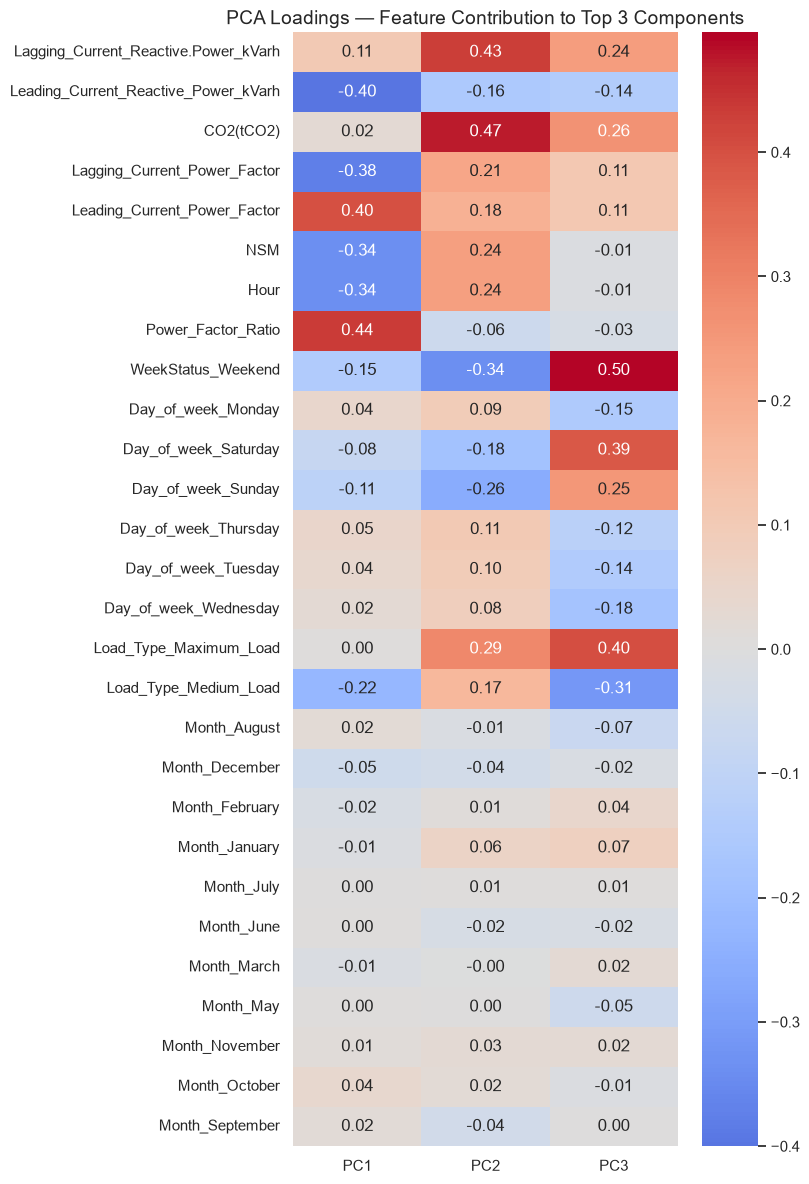

In [18]:
# Get loadings (feature contributions) for first 3 components
loadings = pca_full.components_[:3].T  # transpose: features as rows, components as columns

loadings_df = pd.DataFrame(
    loadings,
    columns=["PC1", "PC2", "PC3"],
    index=X.columns
)

plt.figure(figsize=(8, 12))
sns.heatmap(loadings_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("PCA Loadings — Feature Contribution to Top 3 Components", fontsize=14)

plt.tight_layout()
plt.savefig("../static/pca_loadings_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 12: Save the Trained Pipeline

Since the goal is to keep accuracy close to Week 2's baseline, and the original (no-PCA) model may still perform best, we save whichever pipeline gives the best trade-off between accuracy and simplicity. This saved pipeline (scaler + PCA + model, or just scaler + model) will be used in Part 2's FastAPI app.

In [19]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Save the original (no-PCA) model pipeline components separately
# (scaler is always needed; PCA is optional depending on which version is deployed)
joblib.dump(scaler, "../models/scaler.joblib")
joblib.dump(model_original, "../models/model.joblib")

# Also save the PCA object and PCA-based model in case needed
joblib.dump(pca_full, "../models/pca.joblib")
joblib.dump(model_pca95, "../models/model_pca95.joblib")

print("Pipeline components saved successfully in ../models/")

Pipeline components saved successfully in ../models/


## Dimensionality Reduction Report

**Did accuracy drop significantly?**
Comparing the original (no PCA) model to the PCA-reduced versions: the 3-component model showed RMSE of _____ (vs. original _____), representing a change of _____%. The 95%-variance model ({n_components_95} components) showed RMSE of _____, much closer to the original performance, since it retains most of the information in the data.

**How many features can safely be removed?**
Based on the cumulative variance curve, only **_____ out of {n_features}** components are needed to retain 95% of the variance in the data — meaning approximately **_____ features could be removed** with minimal information loss.

**Would you recommend PCA for a memory-constrained device?**
Yes/No — _____ (justify: e.g., "Yes, because reducing from {n_features} features to {n_components_95} components significantly reduces memory and computation needs while retaining most of the predictive accuracy, making it well-suited for edge devices or embedded systems with limited resources.")